# Introduction to the Fourier Transform

The Fourier Transform is a mathematical tool that allows us to decompose these complex signals into a series of simple, constituent sine and cosine waves of varying frequencies and amplitudes. 

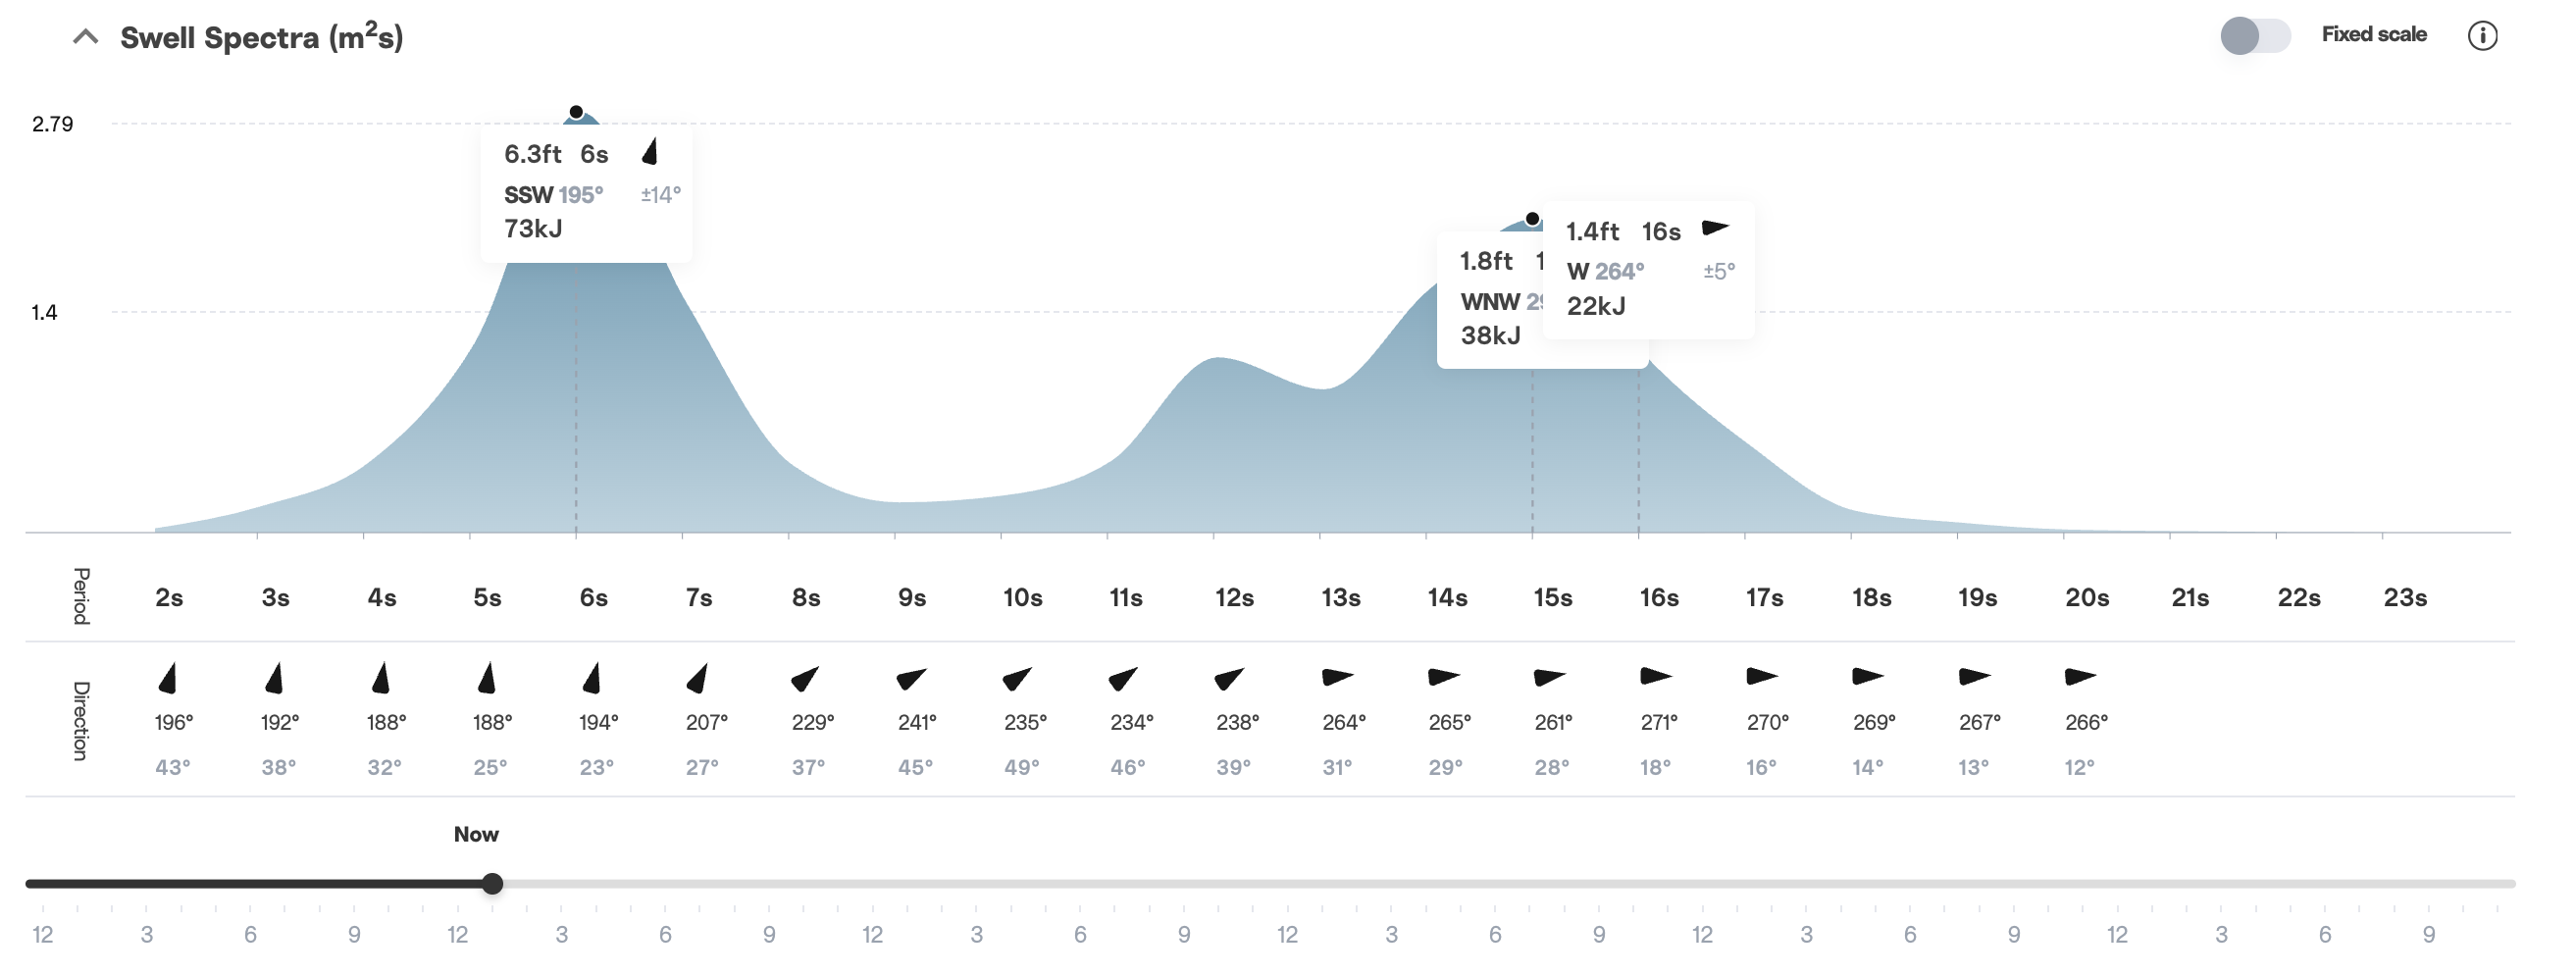
(Surfline uses Fourier Transforms!)


Instead of viewing our data in the **time domain** (e.g., wave height vs. time), the Fourier Transform lets us view it in the **frequency domain** (e.g., wave energy vs. frequency). This is a foundational technique for identifying dominant wave periods, separating high-frequency wind waves from lower-frequency swell, or filtering out instrumental noise.

In this demo, we will build a simple wave, compute its Fourier Transform, and see how modifying the time series changes its frequency representation.

In [2]:
## Functions to use 
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
## Create a time vector 
N = 64
dt = 1
t = np.arange(0, N) * dt

### Part 1
* Form a cosine time series (x) with **amplitude=3m** and **period=16s**.
* Compute the Fourier Transform (X) of x using `np.fft.fft()`
* Plot x and Fourier coefficiencents (`np.real(X)/N` and `np.imag(X)/N`)

In [9]:
# amplitude
A = 3 # meters
# period
T = 16 # seconds
# time series, x
x = A * np.cos(2 * np.pi * t / T)

Fourier transform and shift -f -> +f

In [10]:
X = np.fft.fft(x)
X = np.fft.fftshift(X)
fN = 1 / (2 * dt) # nyquist frequency
df = 1/ (N*dt) # freq resolution

f = np.arange(-fN, fN, df)

Plot time series, real and imaginary Fourier coefficients

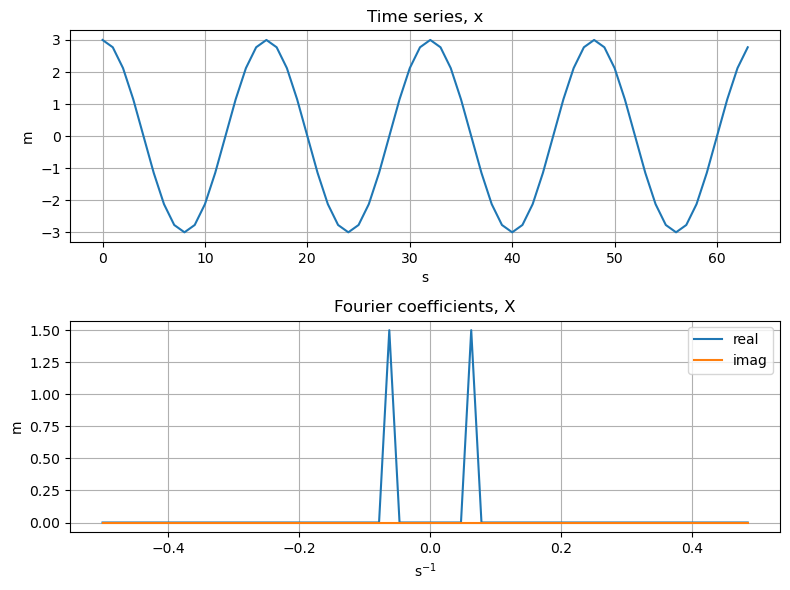

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Time series plot
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients plot
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Understanding the Code: FFT, Shifting, and Frequencies

In Part 1, we used `np.fft.fft()` to compute the Fast Fourier Transform (FFT) of our 16-second cosine wave. Here is a breakdown of the functions used to understand the output::

1. **`fftshift`**: The standard FFT algorithm outputs the positive frequency components first, followed by the negative frequency components. We use `np.fft.fftshift()` to rearrange the array so that the zero-frequency component (the mean of the signal) is physically in the center of our plot, flanked by negative and positive frequencies.
2. **Nyquist Frequency (`fN`)**: The highest frequency we can effectively resolve is strictly determined by our sampling rate (`dt`). This upper limit is called the Nyquist frequency ($f_N = \frac{1}{2 \cdot dt}$). 
3. **Real vs. Imaginary**: The Fourier transform produces complex numbers. The **real** part corresponds to the amplitude of the cosine components, and the **imaginary** part corresponds to the sine components. 

Now it's your turn. Let's see what happens to the Fourier coefficients when we alter the original time series.

### Part 2
* Repeat (1) but adding a constant values of 1m to x

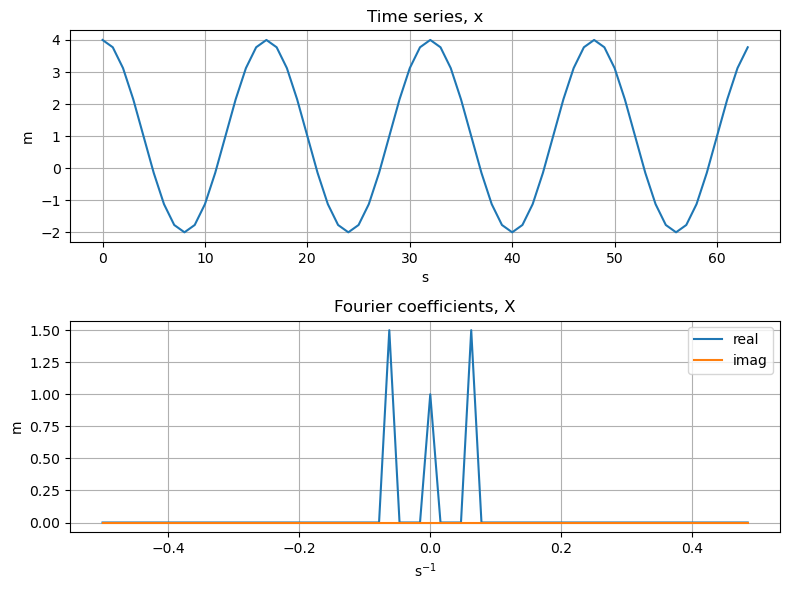

In [12]:
# time series
A = 3
T= 16
x = A * np.cos(2 * np.pi * t / T) + 1

# fouriet ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

#### The DC Offset

Notice how adding a constant of 1m shifted our entire time series up, but it didn't change the underlying period of the wave itself. 

In the frequency domain, this constant value shows up as a massive spike exactly at $f = 0$. In signal processing, this is called the **DC offset**, but in oceanography, we usually think of this as the **mean water level**  upon which our waves are riding. The FFT perfectly separated the mean water level ($f=0$) from the wave energy ($f \neq 0$).

### Part 3
* Repeat (1) but replace the cosine with a sine wave of the same period and amplitude

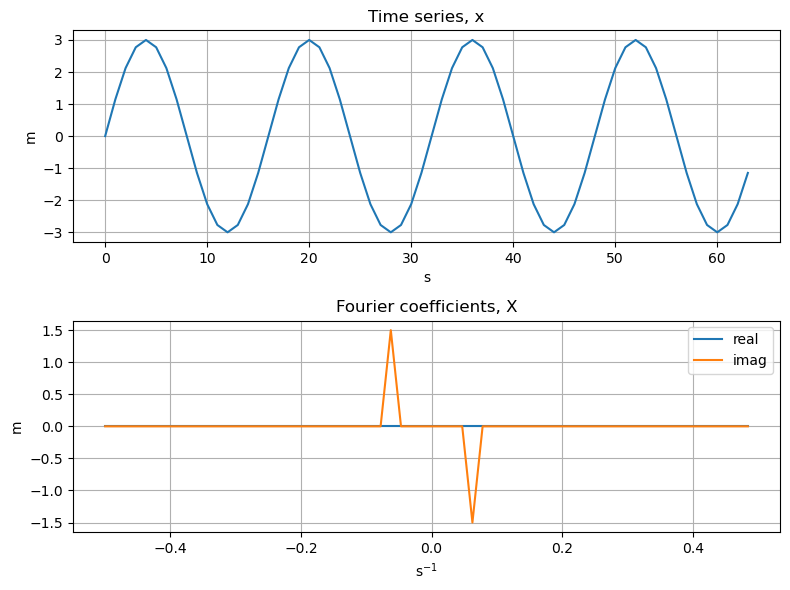

In [13]:
# time series
A = 3
T= 16
x = A * np.sin(2 * np.pi * t / T)

# fouriet ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 4:
* Repeat (1) but add a sine with **amplitude = 2m** and **period = 16s**

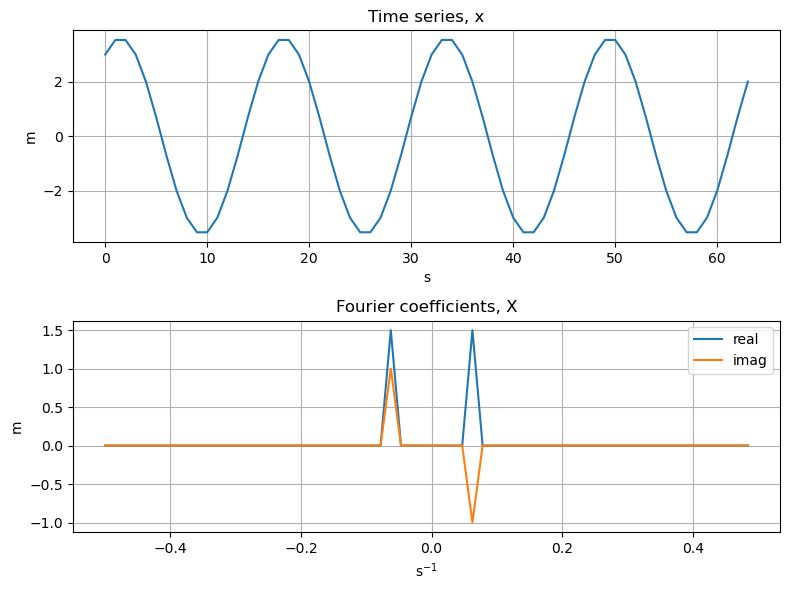

In [14]:
# time series
A = 3
T= 16
x = A * np.cos(2 * np.pi * t / T) + (2 * np.sin(2 * np.pi * t / 16))

# fouriet ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 5:
* Repeat (1) but add a sine with **amplitude = -1m** and **period = 8s**


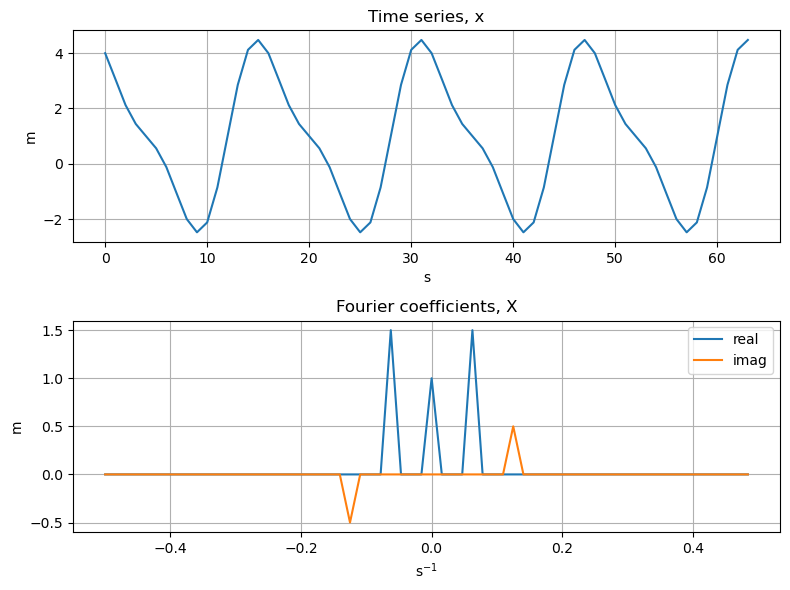

In [ ]:
# time series
A = 3
T= 16
xcos = A * np.cos(2 * np.pi * t / T) + 1
xsin = -1 * np.sin(2 * np.pi * t / 8)
x = xcos + xsin
# fourier ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 6:
* Repeat (1) with **amplitude = 3m** and **period = 2s** (nyquist)

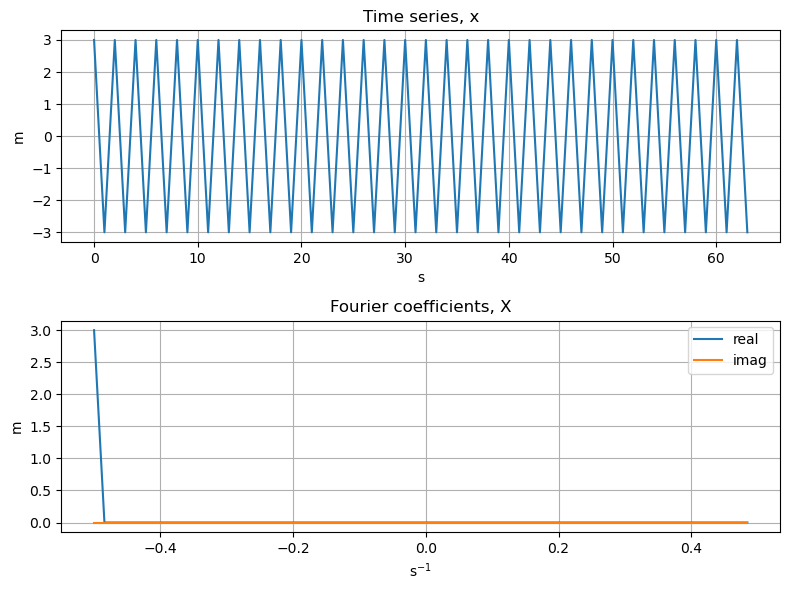

In [16]:
# time series
A = 3
T= 2
x = A * np.cos(2 * np.pi * t / T)

# fourier ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 7:

* Repeat (1) with **amplitude = 3m** and **period = 14s**


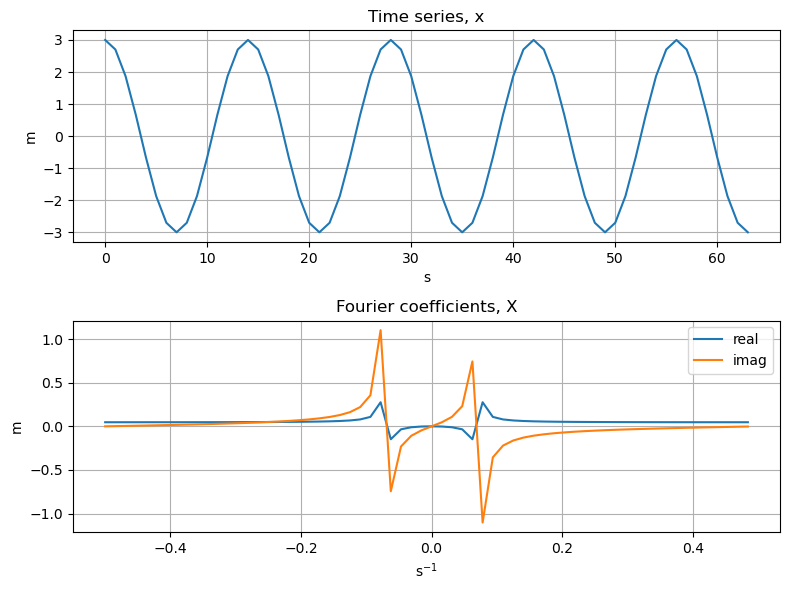

In [17]:
# time series
A = 3
T= 14
x = A * np.cos(2 * np.pi * t / T) 

# fouriet ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 8:
*   Form a time series (x) that is all zeros with a single spike of **amplitude = 1m at t = 32 s.**
* Compute the Fourier transform (X) of x
*  Plot x and Fourier coefficients (real(X)/N, imag(X)/N, abs(X)/N)

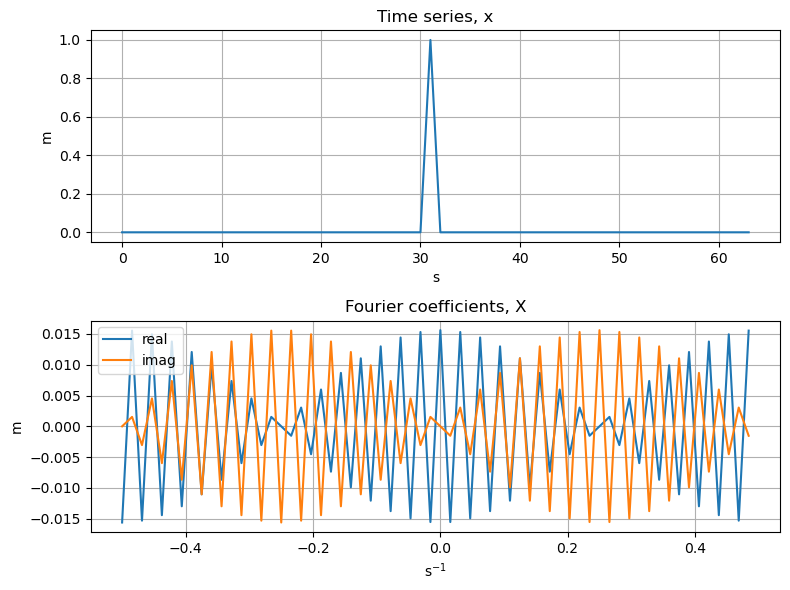

In [22]:
x = np.zeros(N)
x[31] = 1

# time seri
# fourier ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 9

* Form a 64 point random time series (x) using `np.random.rand()`
* remove the mean from x
* compute the Fourier transform (X) of x
* Plot x and Fourier coefficients (`np.real(X)/N, np.imag(X)/N, np.abs(X(/N`)

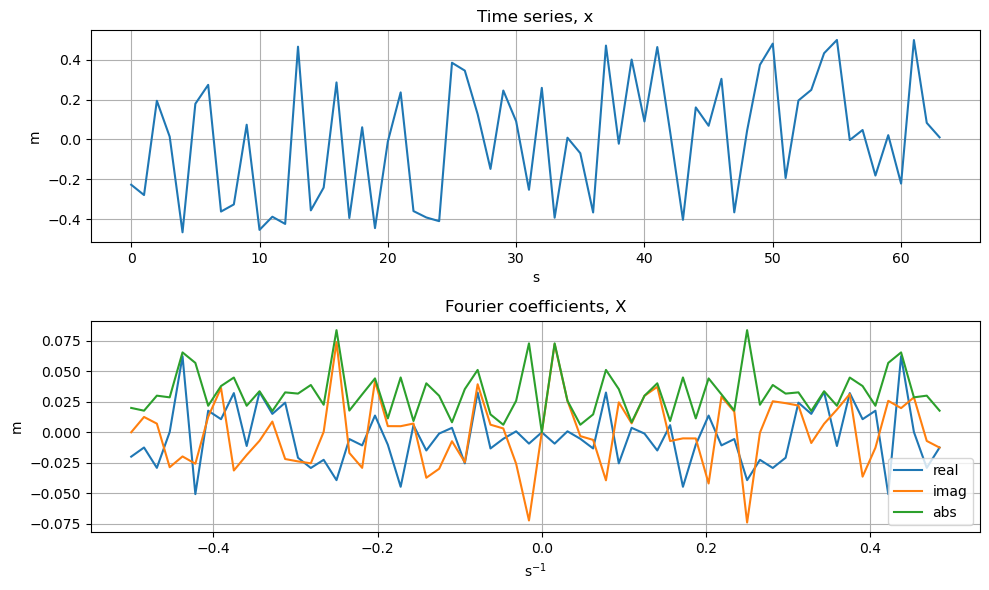

In [27]:
# time series
x =  np.random.rand(N)
x = x - np.mean(x)

# fouriet ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.plot(f, np.abs(X)/N, label='abs')
ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Part 10

*  Form a 64 pt time series (x) that is a straight line trend from 0 to 3m
*  Remove the mean from x
*  Compute the Fourier transform (X) of x
*  Plot x and Fourier coefficients (real(X)/N, imag(X)/N, abs(X)/N)


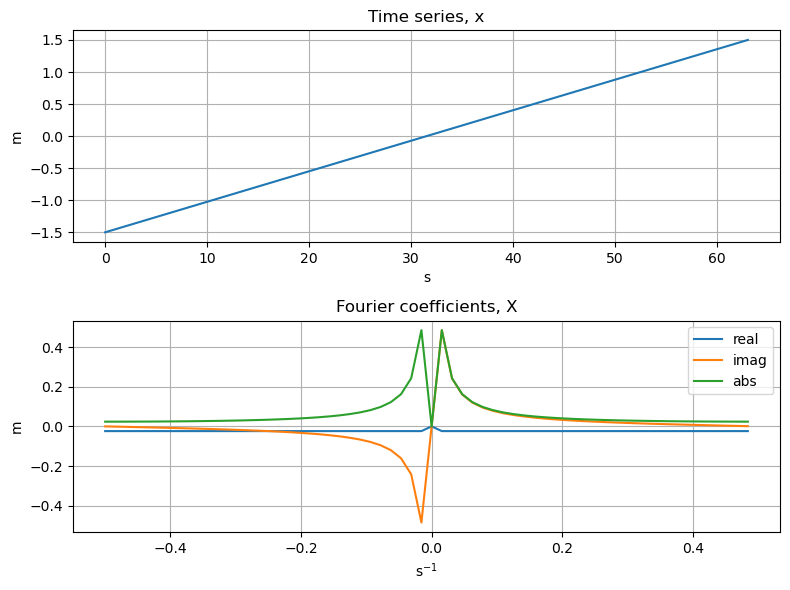

In [28]:
# time series
x = np.linspace(0, 3, N)
x = x - np.mean(x)

# fourier ransform
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# time series
ax1.plot(t, x)
ax1.set_xlabel('s')
ax1.set_ylabel('m')
ax1.set_title('Time series, x')
ax1.grid(True)

# Fourier coefficients
ax2.plot(f, np.real(X)/N, label='real')
ax2.plot(f, np.imag(X)/N, label='imag')
ax2.plot(f, np.abs(X)/N, label='abs')

ax2.legend()
ax2.set_xlabel('s$^{-1}$')
ax2.set_ylabel('m')
ax2.set_title('Fourier coefficients, X')
ax2.grid(True)

plt.tight_layout()
plt.show()